# Cash Conversion Cycle — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · the precedes-margin regression · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Precedes margin%3F: Faint](https://img.shields.io/badge/Precedes_margin%3F-Faint-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **shortening the CCC frees cash, out-earns, and the stock follows** — splits into a mechanism piece and a return piece. This is distinct from every sibling on the desk: [853](../../853-days-sales-outstanding/) is the *receivables* leg alone, [529](../../529-inventory-growth/) the *inventory* leg, [153](../../153-net-operating-assets/) the balance-sheet-bloat *level* scaled by assets. This ranks on the **whole netted cycle**, DSO + DIO − DPO, year-over-year.

> ⚠️ **Data note.** EDGAR `AccountsReceivableNetCurrent` + `InventoryNet` + `AccountsPayableCurrent` + `Revenues` + `CostOfRevenue` (COGS fallback `CostOfGoodsAndServicesSold`), longest per-name history, + yfinance adjusted closes. As-of 2026-06-30 — 30 names, 689 filing-quarters, period ends 2009-07-31 → 2026-05-02. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket). Thin/uneven five-fact coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `d82e55a0af11`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ccc_signal import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 30, 'n_events': 689, 'end_lo': '2009-07-31', 'end_hi': '2026-05-02', 'fp_prices': 'd82e55a0af11', 'n_months': 190, 'avg_n': 13.9, 'ls_span_lo': '2010-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -47.1, 'ls_ann': -5.65, 'ls_t_iid': -1.37, 'ls_t_nw': -1.03, 'ls_sharpe': -0.34, 'ls_hit': 47, 'ls_hit_lo': 40, 'ls_hit_hi': 54, 'ls_long_bps': 125.1, 'ls_short_bps': 172.2, 'ls_turn': 0.17, 'ls_cum': 0.33, 'ls120_mean_bps': -70.5, 'ls120_t_nw': -1.45, 'pct_mean_bps': -2.8, 'pct_t_nw': -0.07, 'pct_sharpe': -0.02, 'xsec_early': 16.4, 'xsec_late': 11.7, 'drift': {21: (687, 1.25, 1.0, 0.25, 0.4, 52, 0.3379), 63: (681, 4.26, 4.59, -0.33, -0.27, 53, 0.6175), 126: (676, 8.43, 8.19, 0.24, 0.09, 52, 0.4562)}, 'mono63': (4.59, 3.33, 4.26), 'era_early_n': 88, 'era_early_bps': 31.9, 'era_early_t': 0.84, 'era_late_n': 102, 'era_late_bps': -115.3, 'era_late_t': -1.54, 'im_n': 487, 'im_slope': -0.0001, 'im_t': -1.13, 'im_r2': 0.003, 'im_corr': -0.051, 'im_low': 0.004, 'im_high': 0.0013, 'im_spread': 0.0027, 'net': {(10, 50): (-54.6, -6.55, -1.19, -0.4), (20, 100): (-62.1, -7.45, -1.36, -0.45)}, 'syn_null_mean': 0.18, 'syn_null_sd': 0.59, 'syn_null_fire': 0, 'syn_null_seeds': 12, 'syn_planted_bps': 907.2, 'syn_planted_t': 18.07}


real cache present: True | events: 689 | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short (long shortening / short bloating) **-47.1 bps/mo** (-5.7%/yr gross), one-sample *t* = -1.37, **Newey-West *t* = -1.03** — wrong-signed and insignificant; staleness-120 *t* = -1.45, pct-change *t* = -0.07; event drift flat and sign-flipping; sign flips by era (+0.84 pre-2018, -1.54 post-2018) |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: -7.45%/yr, NW *t* = -1.36, Sharpe -0.45; **deeply negative** |
| **Precedes margin?** | `FAINT` | next-q gross-margin regression slope -0.00010 (corr -0.05), shortening−bloating tercile spread **+0.27 pp** — correctly signed, economically negligible |

> 💡 In plain words: the working-capital 'virtue' is a wrong-signed null on returns and only a whisper on margin. On big, liquid, heavily-covered names, five accounting lines anyone can pull predict neither the stock nor (much) the profitability they're built from.

## 1 · The claim, steelmanned

Let name $i$'s cash conversion cycle at fiscal quarter $q$ be $\text{CCC}_{i,q} = \text{DSO}_{i,q} + \text{DIO}_{i,q} - \text{DPO}_{i,q}$, each leg a balance ÷ an annualised flow (receivables ÷ sales, inventory ÷ COGS, payables ÷ COGS), disclosed on filing date $F_{i,q}$. The signal is the point-in-time YoY change $\Delta_{i,q} = \text{CCC}_{i,q} - \text{CCC}_{i,q-4}$, known at $F_{i,q}$. The claims:

- **H₁ (precedes margin).** A falling $\Delta$ precedes a *widening* gross margin next quarter — the operating mechanism.
- **H₂ (leads returns).** A cross-sectional long-short on $-\Delta$ (long shorteners) earns a positive forward return spread — the mispricing claim.
- **H₃ (tradable).** That spread survives realistic long-short costs + borrow.

We find **H₁ only faintly supported** (slope -0.00010, corr -0.05, +0.27 pp tercile spread — right sign, trivial size), **H₂ not supported and if anything reversed** (NW *t* = -1.03; the falling-CCC leg *under*-earns the rising-CCC leg; flat non-monotone event drift; the sign flips across the 2018 break), and therefore **H₃ moot** (a deeply negative net spread). The operations-finance literature ties a shorter CCC to higher *profitability* in a broad cross-section; our large-cap, liquid tape is the hardest place for that to translate into a *return* edge, and it does not — hence a `NONE`, not a `WEAK`, on returns.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, precisely because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin (five matched facts per quarter), so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the precedes-margin regression is graded on **magnitude** (its pooled *t* ignores quarter clustering).

## 3 · How we'd know — the protocol

- **Panel.** 689 (ticker, filing) CCC quarters across 30 names, period ends 2009-07-31 → 2026-05-02, each stamped with its 10-Q/10-K filing date (point-in-time). The CCC needs five matched facts a quarter, so the clean cross-section (avg 13.9 names/month) is thinner than the 45-name price basket.
- **Primary.** Monthly tercile long-short on `ccc_score` (= −ΔCCC), one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, Wilson-interval hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the unit-free percentage-change signal `ΔCCC/CCC`; an era split at 2018 (the ASC-606 revenue-tagging break).
- **Mechanism.** Pooled OLS of next-quarter gross-margin change on `ccc_yoy_chg`; expected slope < 0.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-lead knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh signals into terciles each month, long the shortening third / short the bloating third equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: -47.1 bps/mo (-5.65%/yr gross), n=190 months, avg cross-section 13.9
  one-sample t = -1.37   Newey-West(6) t = -1.03   Sharpe -0.34   hit 47%   turnover 0.17
  pct-change signal: -2.8 bps/mo, NW t = -0.07, Sharpe -0.02


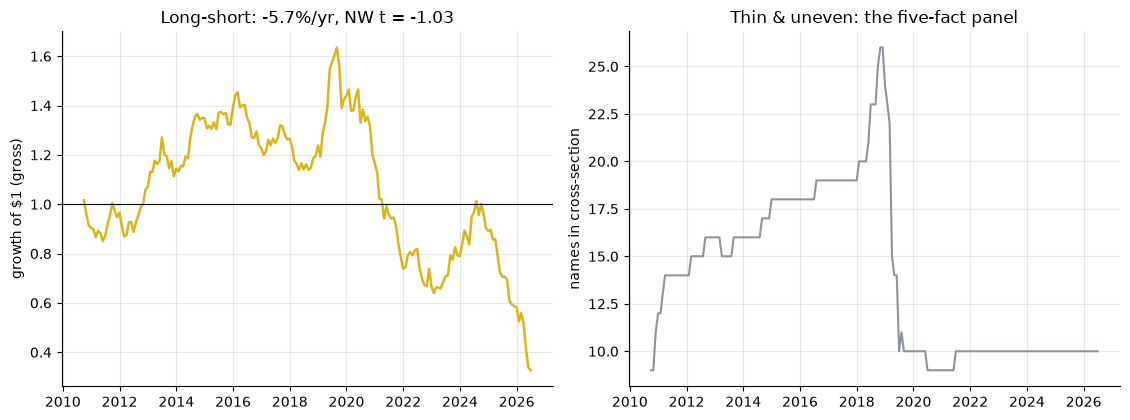

frozen: -47.1 bps/mo, NW t = -1.03, staleness-120 NW t = -1.45, pct-change NW t = -0.07


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='ccc_score', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_pct = st.calendar_ls(PX, EV, signal_col='ccc_pct_score', n_buckets=3, min_names=6, staleness_days=200)
    s_pct = st.calendar_ls_stats(ls_pct)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  pct-change signal: {s_pct['mean_bps']:+.1f} bps/mo, NW t = {s_pct['t_nw']:+.2f}, Sharpe {s_pct['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=AMBER, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: the five-fact panel')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, pct-change NW t = {R['pct_t_nw']:+.2f}")

> 💡 In plain words: **-47 bps/month** (-5.7%/yr gross) is *wrong-signed* — the falling-CCC (long) leg under-earns the rising-CCC (short) leg, the opposite of the efficiency claim — and the HAC *t* is **-1.03**, indistinguishable from zero over n=190 months (avg cross-section 14). The point estimate isn't even stably negative: the staleness-120 cut is -70 bps (*t* = -1.45) and the unit-free percentage-change signal is a flat -3 bps (*t* = -0.07). Whatever this is, it isn't a robust sort in the claimed direction — and the full-sample negative is itself a post-2018 artefact (see 4c).

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by signal; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

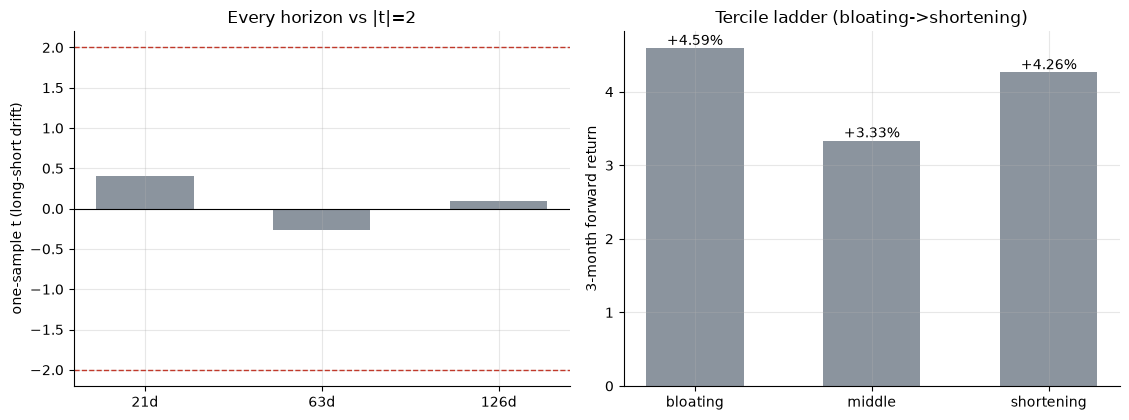

  H= 21d: long-short +0.25%  t=+0.40  win=52%  placebo p=0.337
  H= 63d: long-short -0.33%  t=-0.27  win=53%  placebo p=0.608
  H=126d: long-short +0.24%  t=+0.09  win=52%  placebo p=0.454


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Every horizon vs |t|=2')
a2.bar(['bloating','middle','shortening'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('Tercile ladder (bloating->shortening)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **flat** and *changes sign* with the horizon — *t* = +0.40 at 21d, -0.27 at 63d, +0.09 at 126d — never within shouting distance of ±2. The label-shuffle placebo *p* runs **0.34-0.62** (a random tercile split matches or beats the real one about half the time), and the 63d terciles are **non-monotone** (+4.59% / +3.33% / +4.26% bloating→shortening — a dip in the middle, and the shortening third doesn't top the bloating one). A horizon-dependent sign on a non-monotone ladder is the signature of noise, not a signal.

### 4c · Era split — nothing hiding in a regime

Split the calendar long-short at 2018 (the ASC-606 revenue-tagging break).

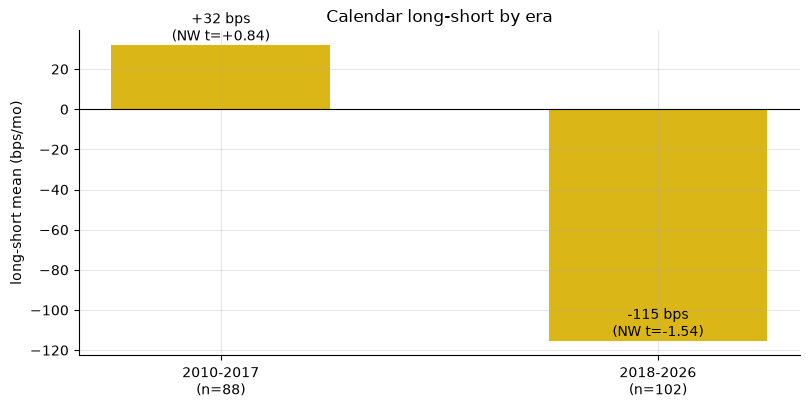

2010-2017: +31.9 bps NW t=+0.84 (n=88)  |  2018-2026: -115.3 bps NW t=-1.54 (n=102)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2018-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2018-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2010-2017\n(n={en})', f'2018-2026\n(n={ln})'], [eb, lb], color=[AMBER, AMBER], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Calendar long-short by era')
plt.tight_layout(); plt.show()
print(f'2010-2017: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2018-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: the sign **flips across the 2018 break** — mildly positive before (+32 bps/mo, NW *t* = +0.84, short of the bar) and firmly negative after (-115 bps/mo, NW *t* = -1.54). The full-sample negative is really a post-2018 artefact, not a stable effect, and neither half certifies. Note the clean cross-section actually *shrinks* (≈16 matched names early, ≈12 late) as ASC-606 revenue-tag switches break the same-fiscal-quarter YoY match — so the modern half is both thinner and the one dragging the sign negative. There is no era in which this certifies in the claimed direction.

### 4d · The mechanism — does shortening the CCC precede a better margin?

Pooled OLS of next-quarter gross-margin change on this quarter's CCC change, and the future-margin spread between the shortening and bloating terciles.

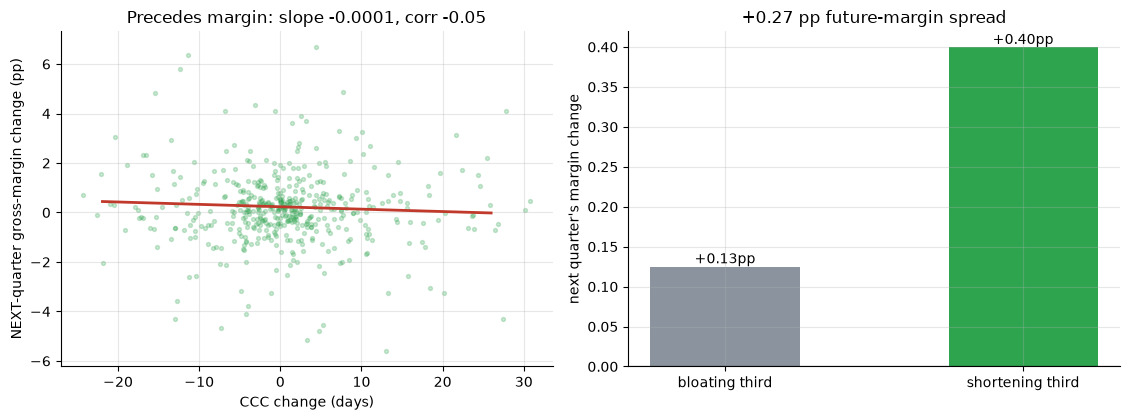

precedes-margin: slope -0.00010, corr -0.051, future-margin spread +0.27 pp (shortening +0.40pp vs bloating +0.13pp)


In [5]:
if HAVE_REAL:
    q = st.improves_margin(EV)
    fr = EV.dropna(subset=['ccc_yoy_chg','next_gm_chg'])
    x, y = fr['ccc_yoy_chg'].to_numpy(), fr['next_gm_chg'].to_numpy()
    slope, corr, lo, hi = q['slope'], q['corr'], q['low_margin']*100, q['high_margin']*100
else:
    x = y = None
    slope, corr, lo, hi = R['im_slope'], R['im_corr'], R['im_low']*100, R['im_high']*100
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<np.percentile(np.abs(x),98))&(np.abs(y)<np.percentile(np.abs(y),98))
    a1.scatter(x[m], y[m]*100, s=8, alpha=.25, color=GREEN)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs, (q['slope']*xs + (y.mean()-q['slope']*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('CCC change (days)'); a1.set_ylabel('NEXT-quarter gross-margin change (pp)')
    a1.set_title(f'Precedes margin: slope {slope:+.4f}, corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['bloating third','shortening third'], [hi, lo], color=[GREY, GREEN], width=.5)
for i,v in enumerate([hi, lo]): a2.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
a2.axhline(0, c='k', lw=.8)
a2.set_ylabel("next quarter's margin change"); a2.set_title(f'{lo-hi:+.2f} pp future-margin spread')
plt.tight_layout(); plt.show()
print(f'precedes-margin: slope {slope:+.5f}, corr {corr:+.3f}, future-margin spread {lo-hi:+.2f} pp (shortening {lo:+.2f}pp vs bloating {hi:+.2f}pp)')

> 💡 In plain words: this is the study's *strongest* result and it's still faint. The slope is **-0.00010** (correctly negative — more CCC shortening, wider next-quarter margin) and the shortening third widens margin **+0.27 pp** more than the bloating third — but the correlation is **-0.05**, R² **0.003**, and the pooled *t* is only **-1.13** (and even that ignores quarter clustering). We read the magnitude, and the magnitude says the 'frees cash → out-earns' mechanism is a real-but-negligible tilt on these names, not a lever.

### 4e · Tradability — the timer

The calendar long-short net of one-way costs × turnover (both legs) + short borrow.

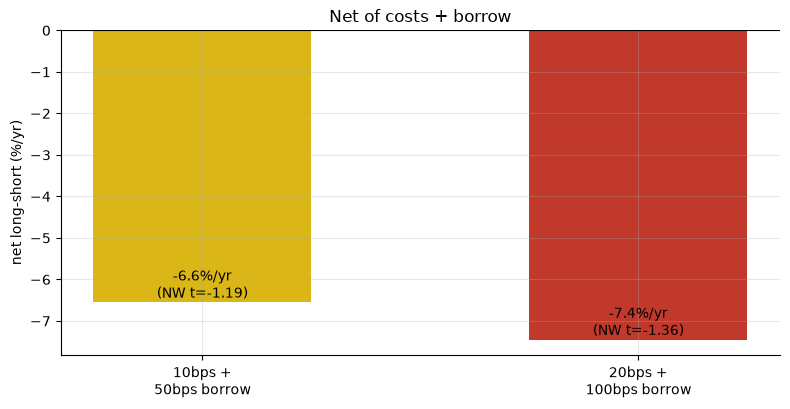

  cost 10bps + borrow 50bps/yr: -6.55%/yr net, NW t=-1.19, Sharpe -0.40
  cost 20bps + borrow 100bps/yr: -7.45%/yr net, NW t=-1.36, Sharpe -0.45


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[AMBER, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Net of costs + borrow')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is modest (~0.17/mo), but there is no gross edge to protect — it was negative to begin with. Light friction (10 bps + 50 bps borrow) leaves -6.55%/yr (*t* = -1.19); a realistic 20 bps + 100 bps borrow deepens it to -7.45%/yr (*t* = -1.36, Sharpe -0.45). **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted lead (shortening-CCC names drift up). The null (edge = 0) is checked over **12 seeds**.

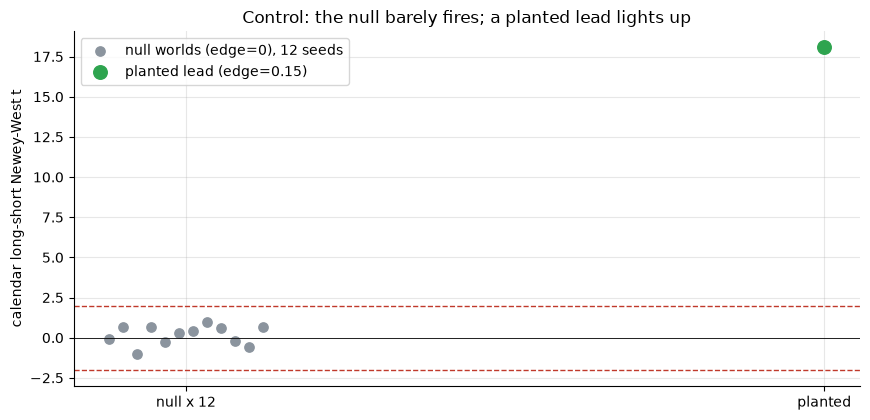

null: mean NW t = +0.18 (sd 0.59), |t|>=2 in 0/12  |  planted NW t = +18.07


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=854 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=854)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted lead (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted lead lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = +0.18 (sd 0.59) and crosses |t|=2 in **0/12** seeds — an unbiased, well-behaved null. A planted lead reads NW *t* = **18.1** (907 bps/mo). So the machinery is faithful and powerful, which means the real-tape -1.03 is a genuine null (indeed a wrong-signed one), not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short -47.1 bps/mo (-5.7%/yr gross), one-sample *t* = -1.37, **Newey-West *t* = -1.03**, and *wrong-signed* (the falling-CCC leg under-earns the rising-CCC leg); staleness-120 and percentage-change variants also fail (-1.45, -0.07); pooled event drift flat and sign-flipping (placebo *p* 0.34-0.62); the sign flips across the 2018 break (+0.84 → -1.54). No coherent, robust effect in the claimed direction — the desk's `NONE`.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -7.45%/yr, NW *t* = -1.36, Sharpe -0.45; deeply negative.
- **Precedes margin? `FAINT`** — regression slope -0.00010, correlation -0.05, **+0.27 pp** shortening-minus-bloating future-margin spread. Correctly signed, economically negligible — the mechanism exists but is a whisper, not the lever the efficiency story promises.

## 6 · Going further

- **The residual worth chasing** is the *surprise* and the *leg mix*, not the headline change: a CCC that falls because payables were stretched (a liquidity warning) is nothing like one that falls because collections improved. Decomposing $\Delta$CCC into its DSO/DIO/DPO contributions, or benchmarking against a seasonal expectation, is where any hidden edge would live.
- **Coverage honesty:** the five-fact panel is thin early; terciles on a thin cross-section are noisy, and the pooled event drift across all events is the more decisive evidence.
- **Dedup map:** [853-days-sales-outstanding](../../853-days-sales-outstanding/) (receivables leg), [529-inventory-growth](../../529-inventory-growth/) (inventory leg), [153-net-operating-assets](../../153-net-operating-assets/) (balance-sheet bloat level / assets), [524-operating-leverage](../../524-operating-leverage/) (cost structure). None ranks on the netted DSO + DIO − DPO cycle change itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*